# Implementação do Perceptron

In [ ]:
import numpy as np

class Perceptron():
  def __init__(self, n_features:int, seed:int=24):
    np.random.seed(seed)
    self.pesos = np.random.rand(n_features + 1).astype(np.float32)

  def _adicionar_bias(self, X):
    '''Cria uma cópia dos dados com coluna extra de 1s'''
    X = np.array(X)
    uns = np.ones((X.shape[0], 1), dtype=np.float32)
    return np.hstack([X, uns])

  def _ativacao(self, u):
    '''Função de ativação do tipo degrau bipolar'''
    return 1 if u >= 0 else -1

  def _forward(self, X):
      u = float(np.dot(X, self.pesos))
      return self._ativacao(u)

  def _erro(self, y_i, y_pred):
    return y_i - y_pred

  def _acuracia(self, y, y_preds):
    return np.mean(y == y_preds)

  def _hebb(self, X_i, erro, lr):
    self.pesos += lr * erro * X_i

  def train(self, X, y, epochs: int, lr: float):
    '''
    Função de treinamento do perceptron.
    Retorna vetor de erros absolutos e acurácias por época.
    '''
    X = self._adicionar_bias(np.array(X, dtype=np.float32))
    y = np.array(y)

    erros = []
    acuracias = []
    for _ in range(epochs):
        erro_epoca = 0
        for i in range(len(X)): # para cada instância
            y_pred = self._forward(X[i])
            erro_amostra = self._erro(y[i], y_pred)
            self._hebb(X[i], erro_amostra, lr)
            erro_epoca += abs(erro_amostra)

        erros.append(erro_epoca)
        y_preds = np.array([self._forward(X[i]) for i in range(len(X))]) # uma forward pass no final da época para calcular a acurácia
        acuracias.append(self._acuracia(y, y_preds))

    return erros, acuracias

  def test(self, X, y):
    '''Função de teste do Perceptron'''
    X = self._adicionar_bias(X)
    y = np.array(y)

    y_preds = np.array([
        self._forward(X[i])
        for i in range(len(X))
    ])
    return self._acuracia(y, y_preds)

  def get_pesos(self):
    return self.pesos

  def get_bias(self):
    return self.pesos[-1]

# Experimentos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def plotar_graficos(erros, acuracia_treino, acuracia_teste, ylim=None):
  plt.figure(figsize=(13, 6))
  plt.subplot(1, 2, 1)
  plt.plot(erros, label='Treino')
  plt.ylabel('Erro De Classificação')
  plt.xlabel('Épocas')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(acuracia_treino, label='Treino')
  plt.xlabel('Épocas')
  plt.ylabel('Acurácia')
  plt.axhline(acuracia_teste, label='Teste', color='orange')
  plt.annotate(f'{acuracia_teste:.5f}', (len(acuracia_treino)/2, acuracia_teste)),
  if ylim:
    plt.ylim(ylim)
  plt.legend()
  plt.show()

## Dataset #1

In [ ]:
train1_path = "/content/train_dataset1.csv"
test1_path = "/content/test_dataset1.csv"

In [ ]:
X_train1 = pd.read_csv(train1_path, usecols=['x1', 'x2'])
y_train1 = pd.read_csv(train1_path, usecols=['label'])

X_test1 = pd.read_csv(test1_path, usecols=['x1', 'x2'])
y_test1 = pd.read_csv(test1_path, usecols=['label'])

In [ ]:
display(X_train1.head())
display(y_train1.head())

,x1,x2
0,0.254018,-0.402391
1,0.180883,0.510887
2,0.227152,0.467715
3,-0.122832,0.502635
4,0.437193,-0.579592


,label
0,-1
1,1
2,1
3,1
4,-1


In [ ]:
perceptron1 = Perceptron(2)
erros1, acuracia_treino1 = perceptron1.train(X_train1, y_train1, 100, 0.1)
acuracia_teste1 = perceptron1.test(X_test1, y_test1)

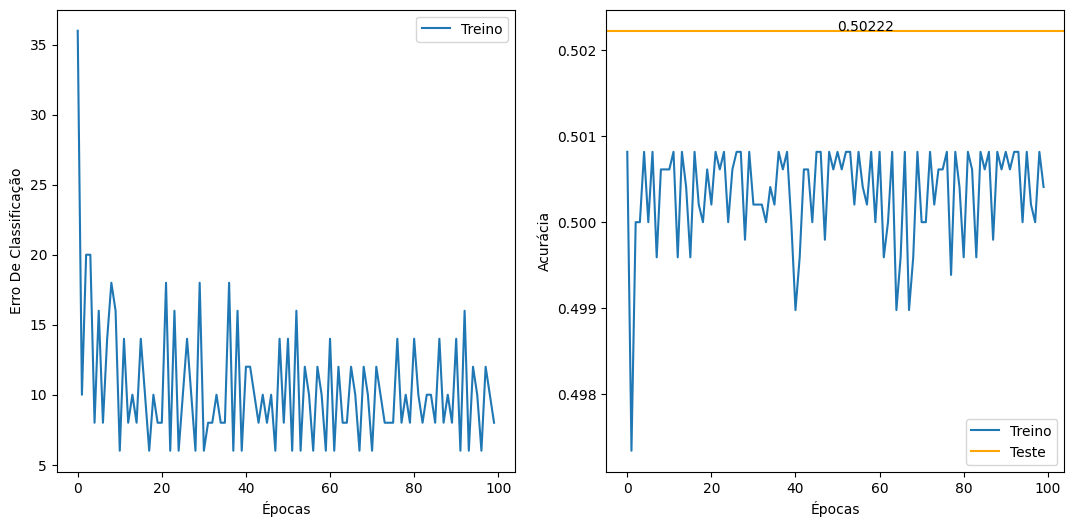

In [ ]:
plotar_graficos(erros1, acuracia_treino1, acuracia_teste1)

Percebe-se bastante oscilação devido à taxa de aprendizado alta, mas há uma tendência de descrescimento do erro e crescimento da acurácia. É provável que uma taxa de aprendizado menor e/ou mais épocas de treinamento acarretassem em um resultado mais satisfatório.

### Extra

In [ ]:
def plot_fronteira(X, y, w, titulo='Perceptron — fronteira de decisão',
                   label_pos='Classe 1', label_neg='Classe -1',
                   classe_pos=1, classe_neg=-1):
    """
    Plota os dados e a fronteira de decisão de um perceptron.

    Parâmetros
    ----------
    X        : array (n, 2) com as features
    y        : array (n,) ou Series com as labels
    w        : vetor de pesos [w1, w2, bias]
    titulo   : título do gráfico
    label_pos: nome da classe positiva na legenda
    label_neg: nome da classe negativa na legenda
    classe_pos: valor da classe positiva em y
    classe_neg: valor da classe negativa em y
    """
    X = np.array(X)
    y = np.array(y).ravel()

    mask_pos = y == classe_pos
    mask_neg = y == classe_neg

    plt.figure(figsize=(7, 5))

    plt.scatter(X[mask_pos, 0], X[mask_pos, 1], c='steelblue', label=label_pos,
                alpha=0.7, edgecolors='white', linewidth=0.5)
    plt.scatter(X[mask_neg, 0], X[mask_neg, 1], c='coral',     label=label_neg,
                alpha=0.7, edgecolors='white', linewidth=0.5)

    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    x2 = -(w[0] * x1 + w[2]) / w[1]

    plt.plot(x1, x2, 'k--', linewidth=1.5, label='Fronteira de decisão')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

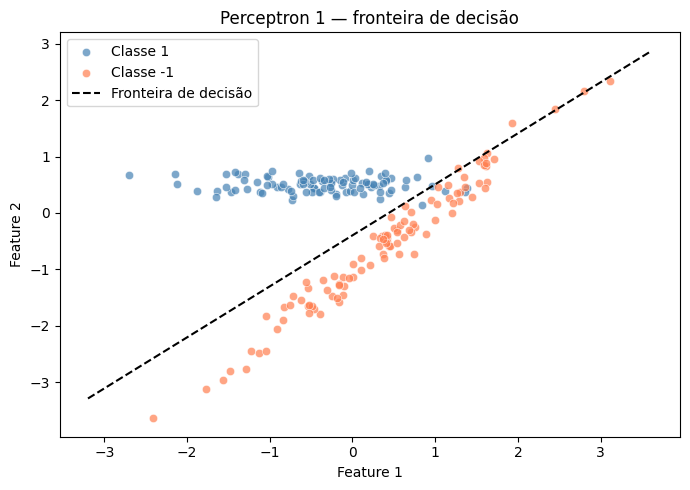

In [ ]:
X = np.append(X_train1.values, X_test1.values, axis=0)
y = np.append(y_train1['label'].values, y_test1['label'].values, axis=0)

plot_fronteira(X, y, perceptron1.get_pesos(), titulo='Perceptron 1 — fronteira de decisão')

Os dados são *quase* linearnmente separáveis, então embora uma performance ótima seja impossível, é estranho que para essa fronteira de decisão esteja sendo calculada uma acurácia de apenas ~0.502

## Dataset #2

In [ ]:
train2_path = "/content/train_dataset2.csv"
test2_path = "/content/test_dataset2.csv"

In [ ]:
X_train2 = pd.read_csv(train2_path, usecols=['x1', 'x2'])
y_train2 = pd.read_csv(train2_path, usecols=['label'])

X_test2 = pd.read_csv(test2_path, usecols=['x1', 'x2'])
y_test2 = pd.read_csv(test2_path, usecols=['label'])

In [ ]:
display(X_train2.head())
display(y_train2.head())

,x1,x2
0,-0.882159,-0.511697
1,0.056971,0.101538
2,0.987759,-0.000616
3,1.108407,0.017528
4,-0.555163,0.770001


,label
0,-1
1,1
2,-1
3,-1
4,-1


In [ ]:
perceptron2 = Perceptron(2)
erros2, acuracia_treino2 = perceptron2.train(X_train2, y_train2, 100, 0.1)
acuracia_teste2 = perceptron2.test(X_test2, y_test2)

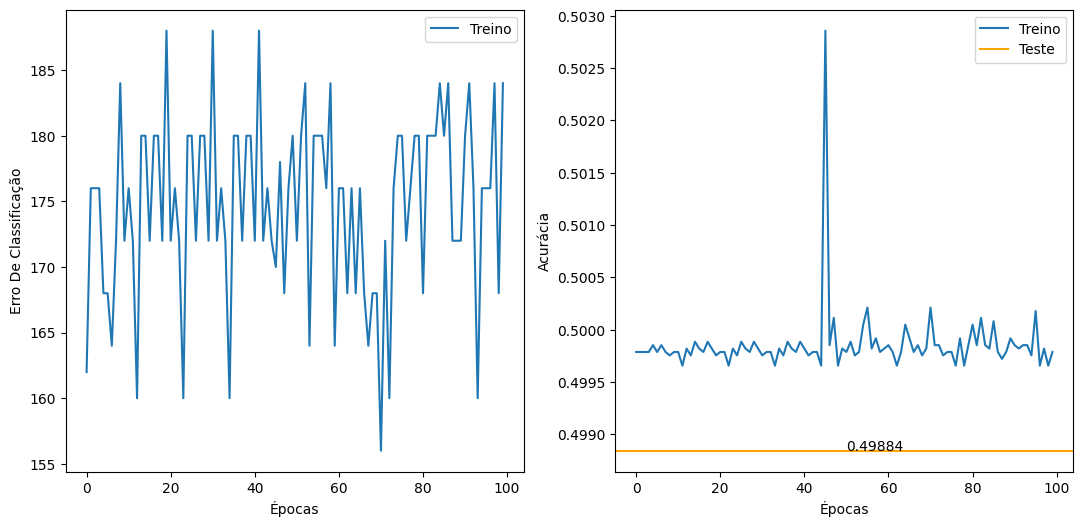

In [ ]:
plotar_graficos(erros2, acuracia_treino2, acuracia_teste2)

Muita oscilação, sem tendência clara de decrescimento do erro, o que pode indicar que os dados não são linearmente separáveis.

### Extra

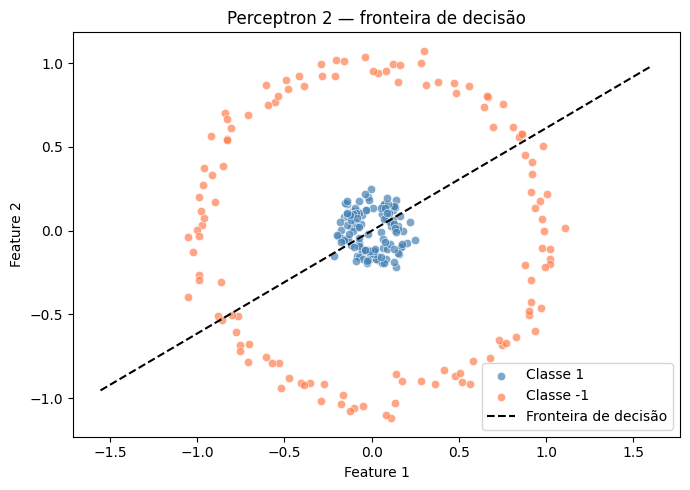

In [ ]:
X = np.append(X_train2.values, X_test2.values, axis=0)
y = np.append(y_train2['label'].values, y_test2['label'].values, axis=0)

plot_fronteira(X, y, perceptron2.get_pesos(), titulo='Perceptron 2 — fronteira de decisão')

Conforme esperado, os dados não são linearmente separáveis.

## Dataset #3

In [ ]:
train3_path = "/content/train_dataset3.csv"
test3_path = "/content/test_dataset3.csv"

In [ ]:
train3 = pd.read_csv(train3_path)
X_train3 = train3.drop(columns=['label'])
y_train3 = train3['label']

test3 = pd.read_csv(test3_path)
X_test3 = test3.drop(columns=['label'])
y_test3 = test3['label']

Learning Rate: 0.1	 Épocas: 100


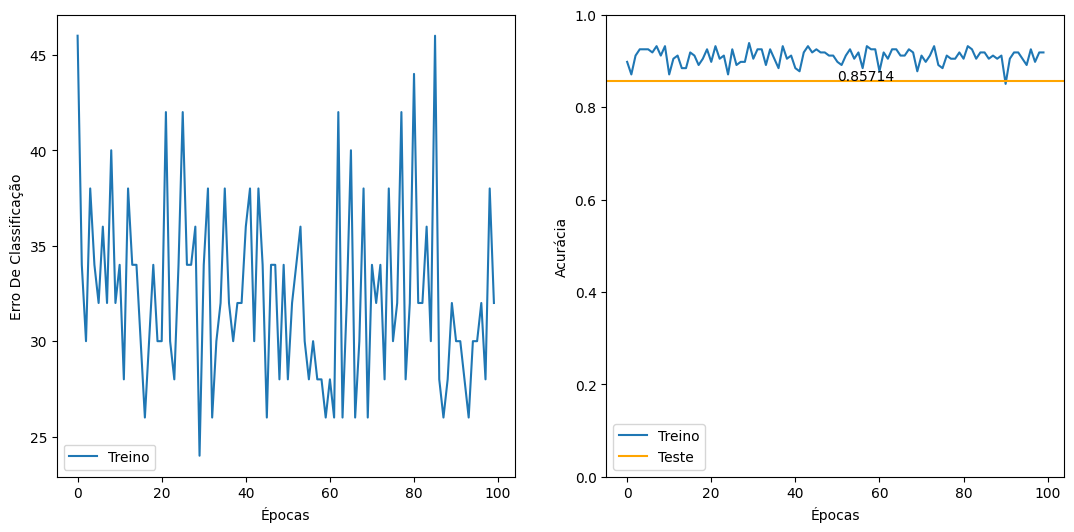

Learning Rate: 0.1	 Épocas: 200


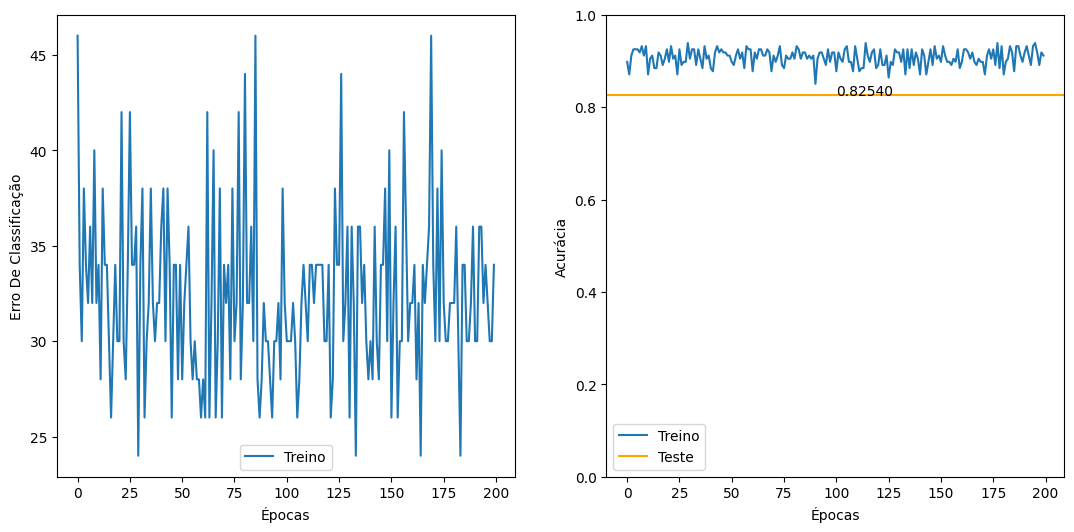

Learning Rate: 0.001	 Épocas: 100


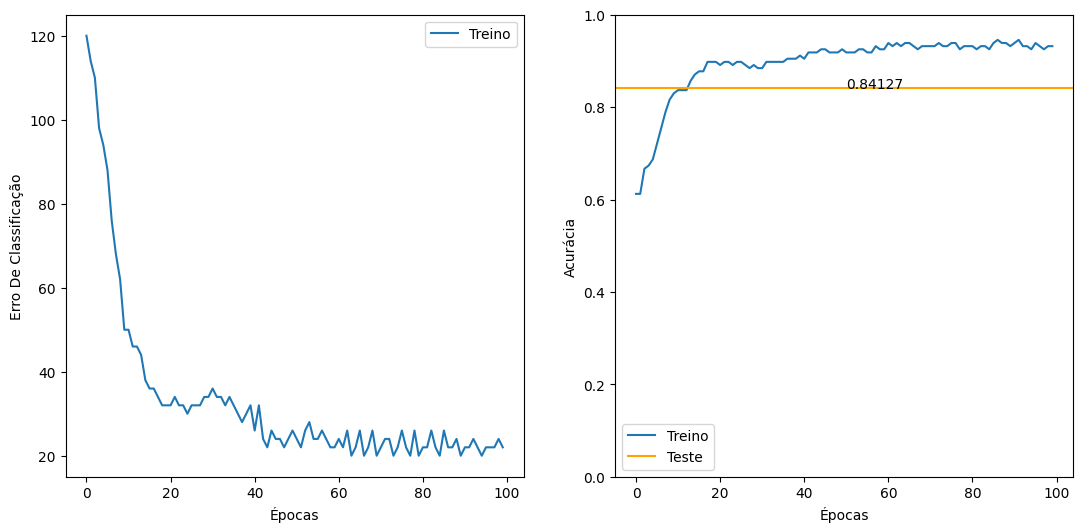

Learning Rate: 0.001	 Épocas: 200


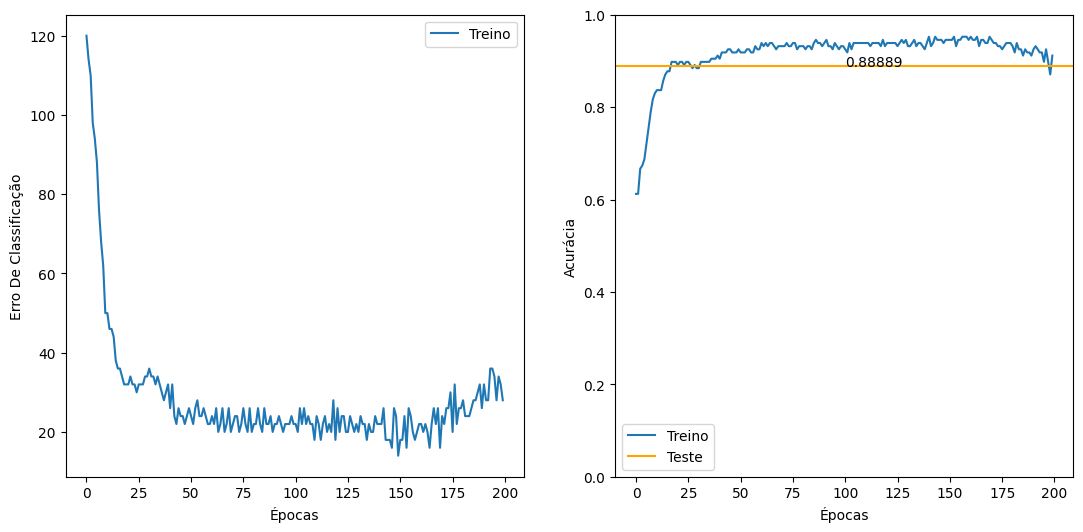

Learning Rate: 0.0001	 Épocas: 100


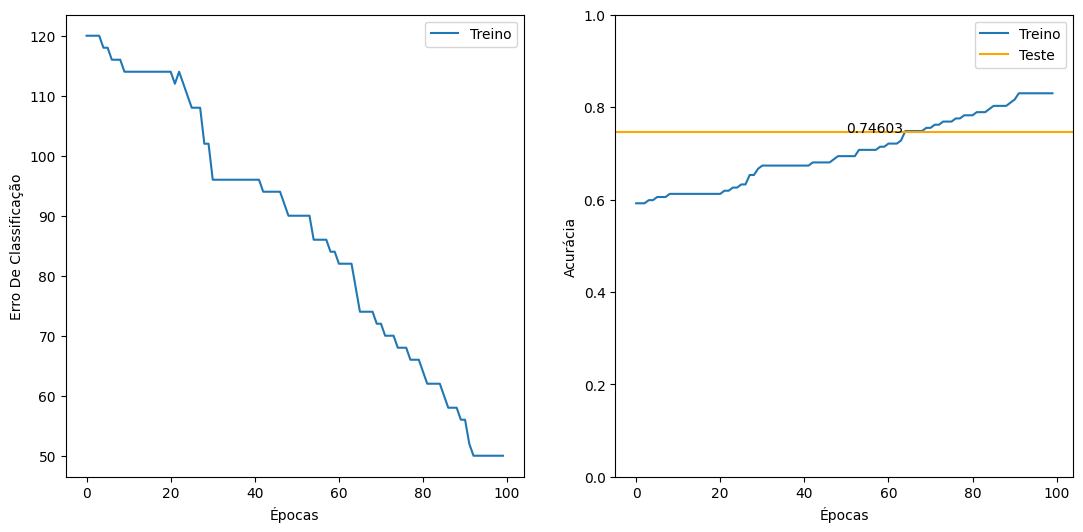

Learning Rate: 0.0001	 Épocas: 200


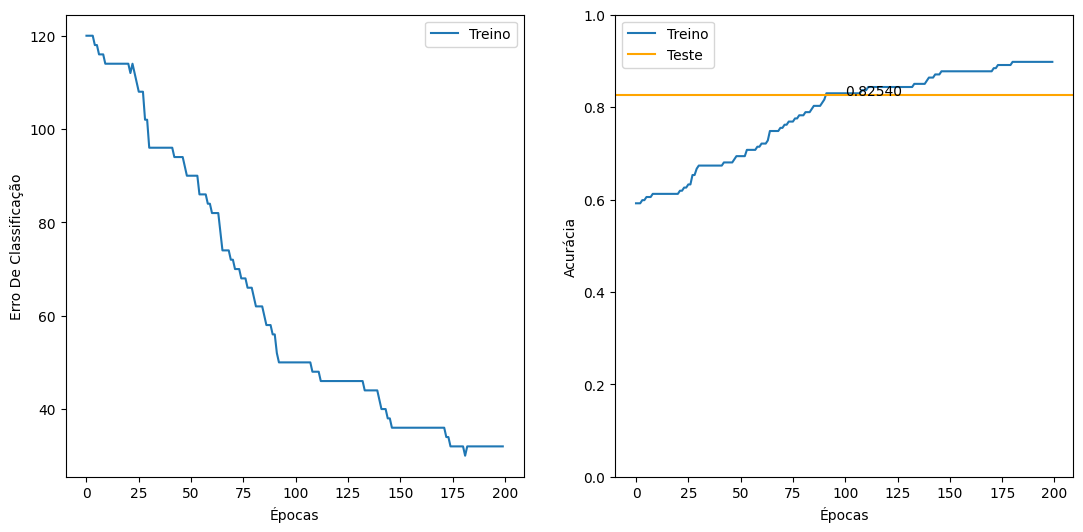

In [ ]:
best_hiperparametros = None
best_acuracia3 = 0

for lr in [0.1, 0.001, 0.0001]:
  for ep in [100, 200]:
    perceptron3 = Perceptron(10)
    erros3, acuracia_treino3 = perceptron3.train(X_train3, y_train3, ep, lr)
    acuracia_teste3 = perceptron3.test(X_test3, y_test3)

    if acuracia_teste3 > best_acuracia3:
      best_acuracia3 = acuracia_teste3
      best_hiperparametros = (lr, ep)

    print(f"Learning Rate: {lr}\t Épocas: {ep}")
    plotar_graficos(erros3, acuracia_treino3, acuracia_teste3, ylim = (0,1))

Percebe-se um comportamento muito mais suave e previsível com taxas de aprendizado menores, embora estas demandem mais épocas de treinamento.

Particularmente, a taxa de aprendizado de 0.1 apresenta altíssima oscilação, igual aos experimentos com o Dataset #1 e Dataset #2. A taxe de 0.001 apresenta a curva de decrescimento da perda mais próxima ao ideal (curva exponencial), embora a taxa de 0.0001 também decresca e, possivelmente, tenda a se aproximar desse ideal com ainda mais épocas de treinamento.

---
Nota-se também que aumentar a quantidade de épocas para a taxa de aprendizado 0.1 na verdade piorou seu desempenho de teste, indicando possível ofverfitting aos dados de treino, ou, simplesmente, ilustrando o alto grau de oscilação.

In [ ]:
print(f"Melhor acurácia: {best_acuracia3}")
print(f"Melhor taxa de aprendizado: {best_hiperparametros[0]}")
print(f"Melhor quantidade de épocas: {best_hiperparametros[1]}")

Melhor acurácia: 0.8888888888888888
Melhor taxa de aprendizado: 0.001
Melhor quantidade de épocas: 200


### Extra

A título de curiosidade, visualizações das combinações 2 a 2 das features e as respectivas projeções do hiperplano de decisão.

In [ ]:
from itertools import combinations

def plot_todas_fronteiras(X, y, w, feature_names=None,
                          titulo_base='Perceptron',
                          classe_pos=1, classe_neg=-1,
                          label_pos='Classe 1', label_neg='Classe -1'):
    """
    Plota a fronteira de decisão para todas as combinações de pares de features.

    Parâmetros
    ----------
    X            : array (n, 10) com as features
    y            : array (n,) com as labels
    w            : vetor de pesos [w1, ..., w10, bias]
    feature_names: lista com nomes das features (opcional)
    titulo_base  : prefixo do título de cada subplot
    classe_pos/neg: valores das classes em y
    label_pos/neg : nomes das classes na legenda
    """
    X = np.array(X)
    y = np.array(y).ravel()
    n_features = X.shape[1]

    if feature_names is None:
        feature_names = [f'Feature {i+1}' for i in range(n_features)]

    pares = list(combinations(range(n_features), 2))
    n_plots = len(pares)

    n_cols = 5
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()

    mask_pos = y == classe_pos
    mask_neg = y == classe_neg

    for idx, (i, j) in enumerate(pares):
        ax = axes[idx]

        # Pontos projetados no par (i, j)
        ax.scatter(X[mask_pos, i], X[mask_pos, j], c='steelblue', label=label_pos,
                   alpha=0.7, edgecolors='white', linewidth=0.5, s=30)
        ax.scatter(X[mask_neg, i], X[mask_neg, j], c='coral', label=label_neg,
                   alpha=0.7, edgecolors='white', linewidth=0.5, s=30)

        # Fronteira projetada: w[i]*x_i + w[j]*x_j + bias = 0
        # Isolando x_j: x_j = -(w[i]*x_i + bias) / w[j]
        if abs(w[j]) > 1e-6:  # evita divisão por zero
            xi_vals = np.linspace(X[:, i].min() - 0.5, X[:, i].max() + 0.5, 200)
            xj_vals = -(w[i] * xi_vals + w[-1]) / w[j]
            ax.plot(xi_vals, xj_vals, 'k--', linewidth=1.2, label='Fronteira')
        else:
            ax.text(0.5, 0.5, 'w[j] ≈ 0\nsem fronteira',
                    transform=ax.transAxes, ha='center', va='center',
                    fontsize=9, color='gray')

        ax.set_xlabel(feature_names[i], fontsize=9)
        ax.set_ylabel(feature_names[j], fontsize=9)
        ax.set_title(f'{feature_names[i]} × {feature_names[j]}', fontsize=9)
        ax.tick_params(labelsize=7)

    # Legenda global no primeiro eixo
    axes[0].legend(fontsize=7, loc='best')

    # Oculta subplots vazios (se n_plots não preenche a grade)
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(titulo_base, fontsize=13, y=1)
    plt.tight_layout()
    plt.show()

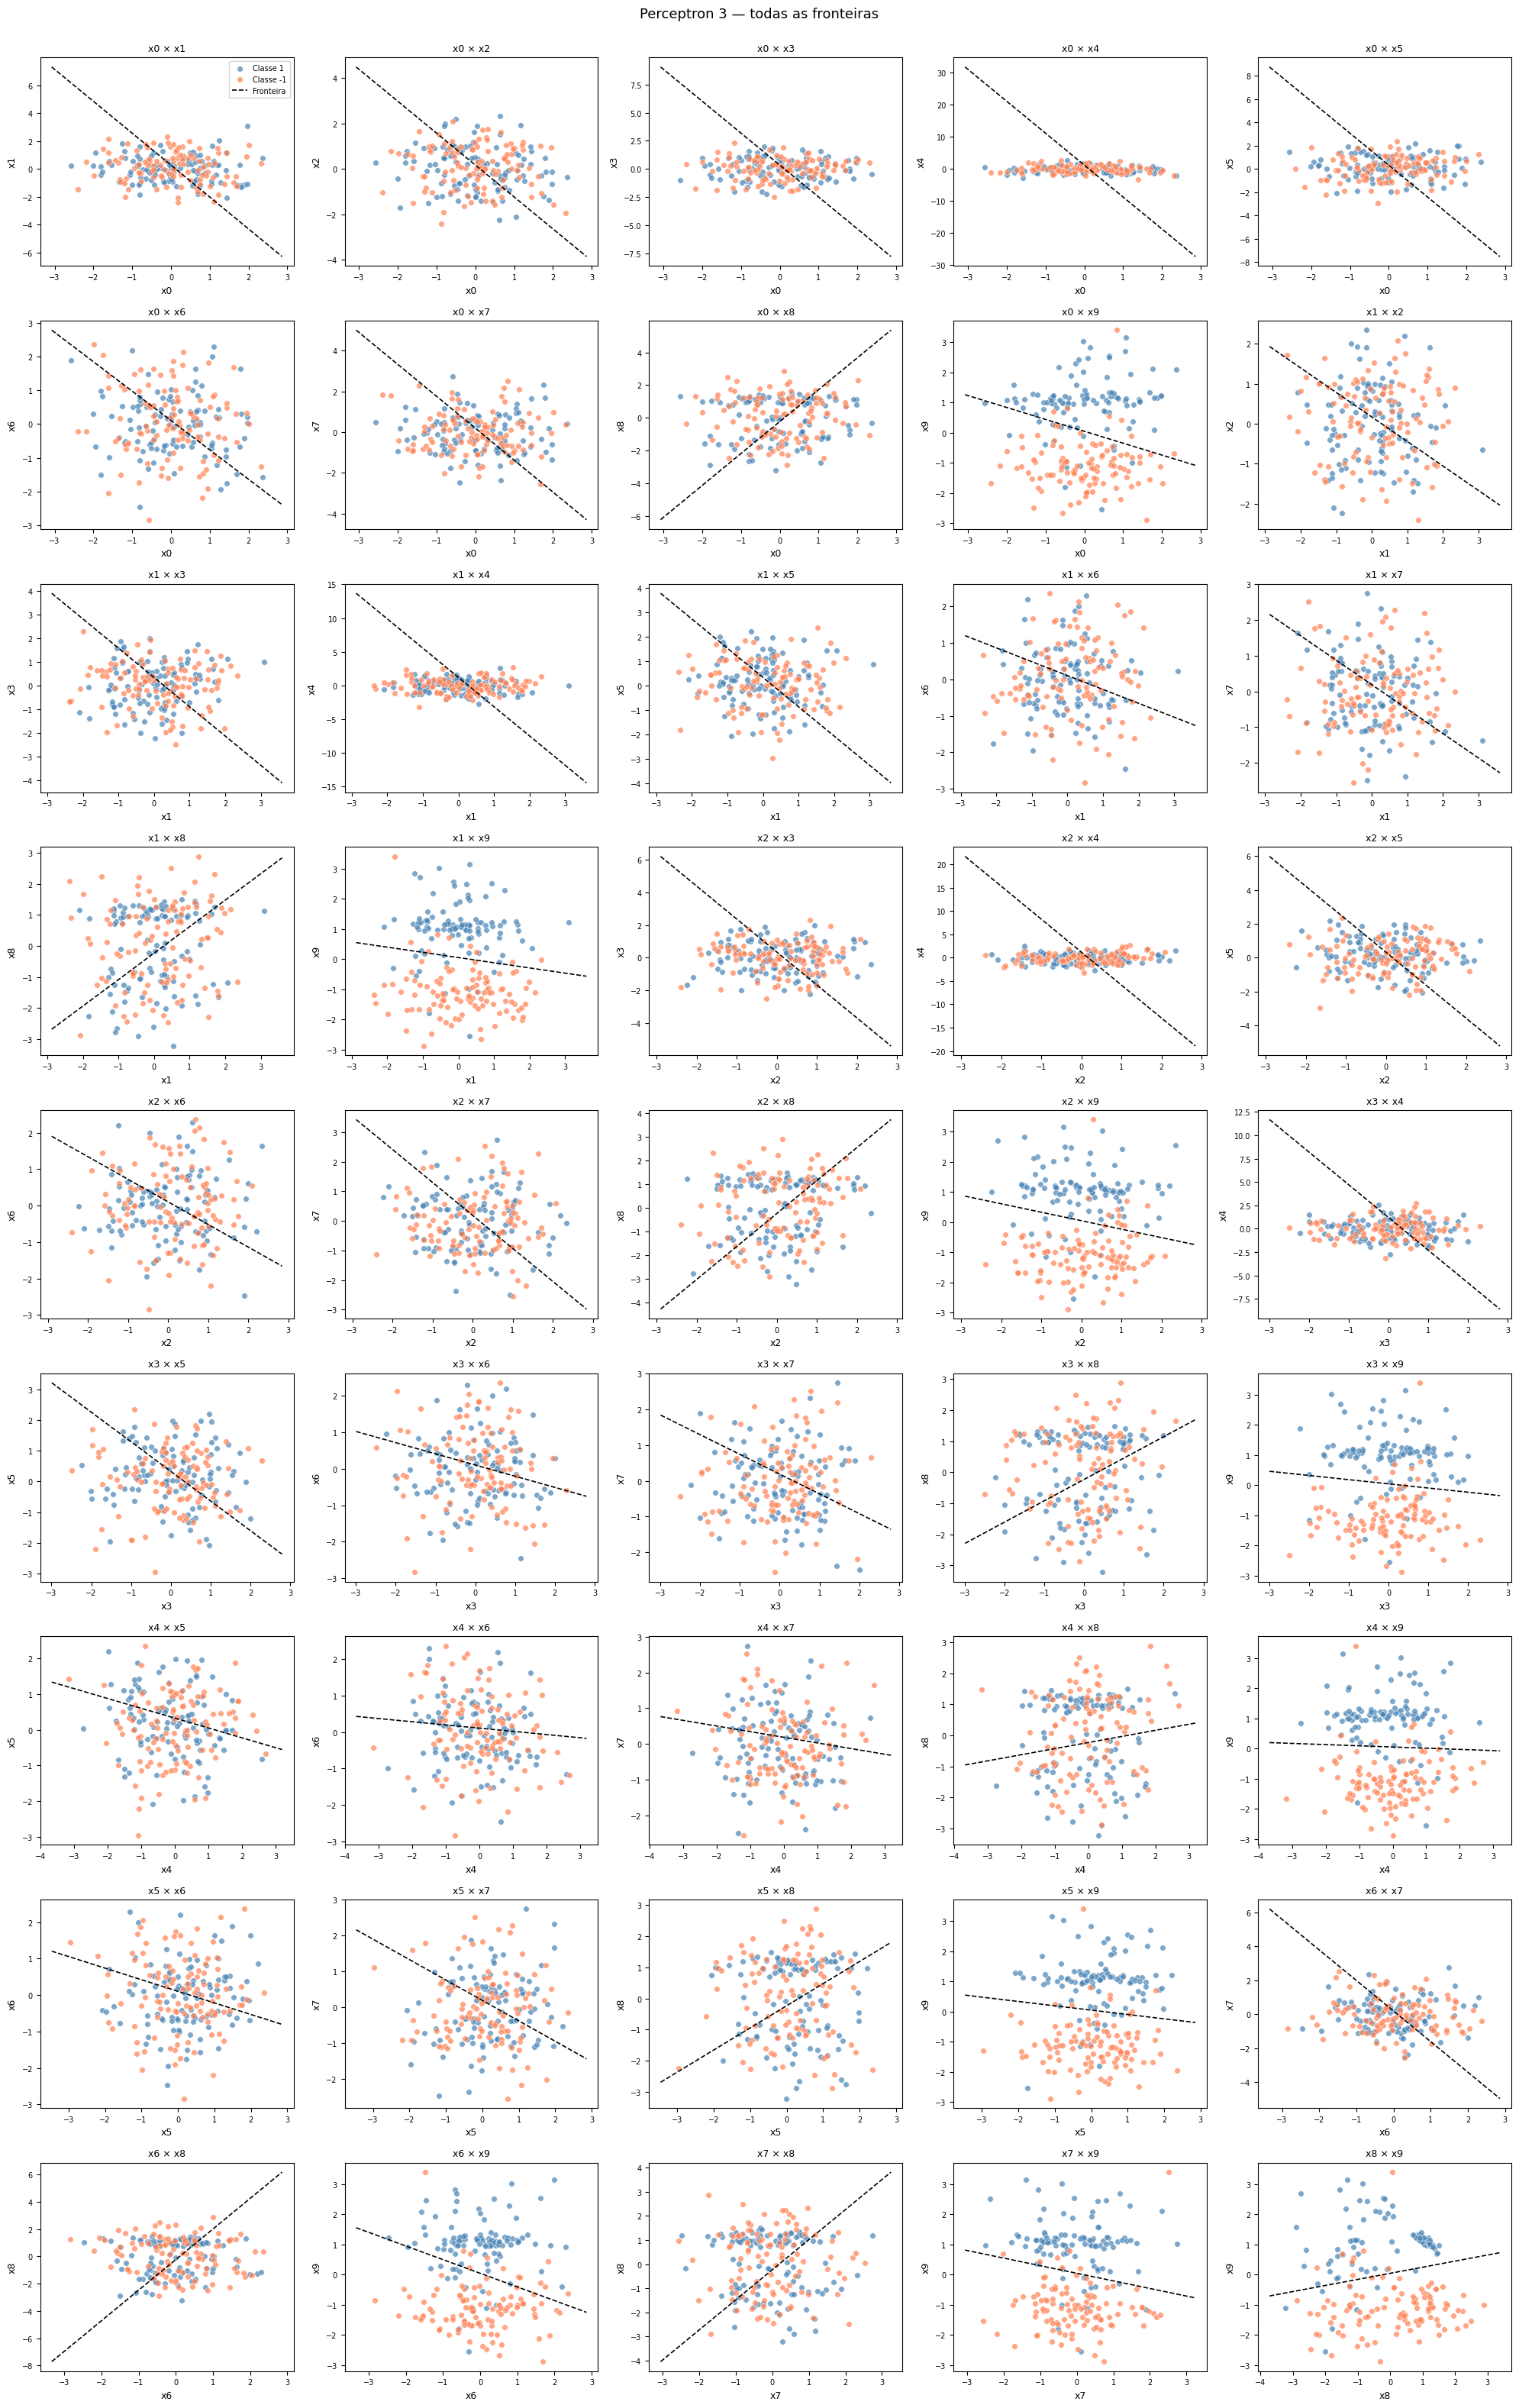

In [ ]:
X = np.append(X_train3.values, X_test3.values, axis=0)
y = np.append(y_train3.values, y_test3.values, axis=0)

plot_todas_fronteiras(
    X, y,
    w=perceptron3.get_pesos(),
    feature_names=[f'x{i}' for i in range(10)],
    titulo_base='Perceptron 3 — todas as fronteiras'
)